<a href="https://colab.research.google.com/github/NathanCarvalho7/Telecom_X_parte1/blob/main/Telecom_X_br_Nathan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📌 Extração


Etapa 1 — Importação das Bibliotecas

In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests

Etapa 2 — Importar os dados da API

In [95]:
url = 'https://raw.githubusercontent.com/ingridcristh/challenge2-data-science/refs/heads/main/TelecomX_Data.json'

In [96]:
dados = requests.get(url)
dados_json = dados.json()
df = pd.DataFrame(dados_json)
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [97]:
df = pd.json_normalize(dados_json)
df.head(5)

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


#🔧 Transformação

Inspeção inicial do dataset

In [98]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

Padronização dos nomes das colunas

In [99]:
df = df.rename(columns={
    "customerID": "id_cliente",
    "Churn": "cancelou",

    "customer.gender": "genero",
    "customer.SeniorCitizen": "idoso",
    "customer.Partner": "parceiro",
    "customer.Dependents": "dependentes",
    "customer.tenure": "meses_contrato",

    "phone.PhoneService": "servico_telefone",
    "phone.MultipleLines": "multiplas_linhas",

    "internet.InternetService": "servico_internet",
    "internet.OnlineSecurity": "seguranca_online",
    "internet.OnlineBackup": "backup_online",
    "internet.DeviceProtection": "protecao_dispositivo",
    "internet.TechSupport": "suporte_tecnico",
    "internet.StreamingTV": "streaming_tv",
    "internet.StreamingMovies": "streaming_filmes",

    "account.Contract": "tipo_contrato",
    "account.PaperlessBilling": "fatura_online",
    "account.PaymentMethod": "metodo_pagamento",
    "account.Charges.Monthly": "cobranca_mensal",
    "account.Charges.Total": "cobranca_total"
})

In [100]:
df.columns

Index(['id_cliente', 'cancelou', 'genero', 'idoso', 'parceiro', 'dependentes',
       'meses_contrato', 'servico_telefone', 'multiplas_linhas',
       'servico_internet', 'seguranca_online', 'backup_online',
       'protecao_dispositivo', 'suporte_tecnico', 'streaming_tv',
       'streaming_filmes', 'tipo_contrato', 'fatura_online',
       'metodo_pagamento', 'cobranca_mensal', 'cobranca_total'],
      dtype='object')

Nova verificação da estrutura dos dados

In [101]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id_cliente            7267 non-null   object 
 1   cancelou              7267 non-null   object 
 2   genero                7267 non-null   object 
 3   idoso                 7267 non-null   int64  
 4   parceiro              7267 non-null   object 
 5   dependentes           7267 non-null   object 
 6   meses_contrato        7267 non-null   int64  
 7   servico_telefone      7267 non-null   object 
 8   multiplas_linhas      7267 non-null   object 
 9   servico_internet      7267 non-null   object 
 10  seguranca_online      7267 non-null   object 
 11  backup_online         7267 non-null   object 
 12  protecao_dispositivo  7267 non-null   object 
 13  suporte_tecnico       7267 non-null   object 
 14  streaming_tv          7267 non-null   object 
 15  streaming_filmes     

Conversão da coluna de cobrança total

In [102]:
df['cobranca_total'].unique()

array(['593.3', '542.4', '280.85', ..., '742.9', '4627.65', '3707.6'],
      dtype=object)

In [103]:
df['cobranca_total'] = pd.to_numeric(
    df['cobranca_total'],
    errors='coerce'
)

In [104]:
df['cobranca_total'].unique()

array([ 593.3 ,  542.4 ,  280.85, ...,  742.9 , 4627.65, 3707.6 ])

Verificação final após transformação

In [105]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id_cliente            7267 non-null   object 
 1   cancelou              7267 non-null   object 
 2   genero                7267 non-null   object 
 3   idoso                 7267 non-null   int64  
 4   parceiro              7267 non-null   object 
 5   dependentes           7267 non-null   object 
 6   meses_contrato        7267 non-null   int64  
 7   servico_telefone      7267 non-null   object 
 8   multiplas_linhas      7267 non-null   object 
 9   servico_internet      7267 non-null   object 
 10  seguranca_online      7267 non-null   object 
 11  backup_online         7267 non-null   object 
 12  protecao_dispositivo  7267 non-null   object 
 13  suporte_tecnico       7267 non-null   object 
 14  streaming_tv          7267 non-null   object 
 15  streaming_filmes     

Verificar valores vazios ou inconsistentes

In [106]:
for col in df.columns:
  print(f'{col}: {df[col].unique()}')
  if df[col].nunique() < 50:
    print(df[col].unique())
    print('-' * 50)

id_cliente: ['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']
cancelou: ['No' 'Yes' '']
['No' 'Yes' '']
--------------------------------------------------
genero: ['Female' 'Male']
['Female' 'Male']
--------------------------------------------------
idoso: [0 1]
[0 1]
--------------------------------------------------
parceiro: ['Yes' 'No']
['Yes' 'No']
--------------------------------------------------
dependentes: ['Yes' 'No']
['Yes' 'No']
--------------------------------------------------
meses_contrato: [ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 11 37 49 66
 67 20 43 59 12 27  2 25 29 14 35 64 39 40  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 53 68 51 31 36 17 18 38 42
  0]
servico_telefone: ['Yes' 'No']
['Yes' 'No']
--------------------------------------------------
multiplas_linhas: ['No' 'Yes' 'No phone service']
['No' 'Yes' 'No phone service']
--------------------------------------------------


In [107]:
df['cancelou'].value_counts()

,count
cancelou,
No,5174
Yes,1869
,224


In [108]:
df = df[df['cancelou'] != '']

In [109]:
df['cobranca_total'].isnull().sum()

np.int64(11)

In [110]:
df = df.dropna()

In [111]:
df['cobranca_total'].isnull().sum()

np.int64(0)

Traduzindo valores das colunas categóricas

In [112]:
#Coluna cancelou
df['cancelou'] = df['cancelou'].replace({
    'Yes': 'Sim',
    'No': 'Não'
})


#Coluna genero
df['genero'] = df['genero'].replace({
    'Female': 'Feminino',
    'Male': 'Masculino'
})


#Coluna parceiro
df['parceiro'] = df['parceiro'].replace({
    'Yes': 'Sim',
    'No': 'Não'
})


#Coluna dependentes
df['dependentes'] = df['dependentes'].replace({
    'Yes': 'Sim',
    'No': 'Não'
})


#Coluna servico_telefone
df['servico_telefone'] = df['servico_telefone'].replace({
    'Yes': 'Sim',
    'No': 'Não'
})

#coluna multiplas_linhas
df['multiplas_linhas'] = df['multiplas_linhas'].replace({
    'Yes': 'Sim',
    'No': 'Não',
    'No phone service': 'Sem telefone'
})

#coluna servico_internet
df['servico_internet'] = df['servico_internet'].replace({
    'DSL': 'DSL',
    'Fiber optic': 'Fibra ótica',
    'No': 'Sem internet'
})

#colunas serviços de internet adicionais
colunas_servicos = [
    'seguranca_online',
    'backup_online',
    'protecao_dispositivo',
    'suporte_tecnico',
    'streaming_tv',
    'streaming_filmes'
]

for col in colunas_servicos:
    df[col] = df[col].replace({
        'Yes': 'Sim',
        'No': 'Não',
        'No internet service': 'Sem internet'
    })


#coluna tipo_contrato
df['tipo_contrato'] = df['tipo_contrato'].replace({
    'Month-to-month': 'Mensal',
    'One year': '1 ano',
    'Two year': '2 anos'
})


#coluna fatura_online
df['fatura_online'] = df['fatura_online'].replace({
    'Yes': 'Sim',
    'No': 'Não'
})

#coluna metodo_pagamento
df['metodo_pagamento'] = df['metodo_pagamento'].replace({
    'Electronic check': 'Cheque eletrônico',
    'Mailed check': 'Cheque enviado',
    'Bank transfer (automatic)': 'Transferência bancária automática',
    'Credit card (automatic)': 'Cartão de crédito automático'
})


In [113]:
for col in df.columns:
  print(f'{col}: {df[col].unique()}')
  if df[col].nunique() < 50:
    print(df[col].unique())
    print('-' * 50)

id_cliente: ['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']
cancelou: ['Não' 'Sim']
['Não' 'Sim']
--------------------------------------------------
genero: ['Feminino' 'Masculino']
['Feminino' 'Masculino']
--------------------------------------------------
idoso: [0 1]
[0 1]
--------------------------------------------------
parceiro: ['Sim' 'Não']
['Sim' 'Não']
--------------------------------------------------
dependentes: ['Sim' 'Não']
['Sim' 'Não']
--------------------------------------------------
meses_contrato: [ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 37 49 66 67
 20 43 59 12 27  2 25 29 14 35 64 39 40 11  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 53 68 31 36 17 18 51 38 42]
servico_telefone: ['Sim' 'Não']
['Sim' 'Não']
--------------------------------------------------
multiplas_linhas: ['Não' 'Sim' 'Sem telefone']
['Não' 'Sim' 'Sem telefone']
---------------------------------------------

Coluna de Contas Diárias

In [114]:
df['conta_diaria'] = df['cobranca_mensal'] / 30

Convertendo apenas as colunas binárias

In [115]:
df.nunique()

,0
id_cliente,7032
cancelou,2
genero,2
idoso,2
parceiro,2
dependentes,2
meses_contrato,72
servico_telefone,2
multiplas_linhas,3
servico_internet,3


In [116]:
colunas_binarias = [
    'cancelou',
    'parceiro',
    'dependentes',
    'servico_telefone',
    'fatura_online'
]

In [117]:
for col in colunas_binarias:
    df[col] = df[col].map({
        'Sim': 1,
        'Não': 0
    })

In [118]:
df[colunas_binarias].head()

,cancelou,parceiro,dependentes,servico_telefone,fatura_online
0,0,1,1,1,1
1,0,0,0,1,0
2,1,0,0,1,1
3,1,1,0,1,1
4,1,1,0,1,1


## Dataset tratado e pronto para análise

#📊 Carga e análise

In [119]:
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id_cliente            7032 non-null   object 
 1   cancelou              7032 non-null   int64  
 2   genero                7032 non-null   object 
 3   idoso                 7032 non-null   int64  
 4   parceiro              7032 non-null   int64  
 5   dependentes           7032 non-null   int64  
 6   meses_contrato        7032 non-null   int64  
 7   servico_telefone      7032 non-null   int64  
 8   multiplas_linhas      7032 non-null   object 
 9   servico_internet      7032 non-null   object 
 10  seguranca_online      7032 non-null   object 
 11  backup_online         7032 non-null   object 
 12  protecao_dispositivo  7032 non-null   object 
 13  suporte_tecnico       7032 non-null   object 
 14  streaming_tv          7032 non-null   object 
 15  streaming_filmes      7032

,cancelou,idoso,parceiro,dependentes,meses_contrato,servico_telefone,fatura_online,cobranca_mensal,cobranca_total,conta_diaria
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.265785,0.162400,0.482509,0.298493,32.421786,0.903299,0.592719,64.798208,2283.300441,2.159940
std,0.441782,0.368844,0.499729,0.457629,24.545260,0.295571,0.491363,30.085974,2266.771362,1.002866
min,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,18.250000,18.800000,0.608333
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,35.587500,401.450000,1.186250
50%,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,70.350000,1397.475000,2.345000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,89.862500,3794.737500,2.995417
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000,3.958333


In [120]:
df.describe(include='object')

,id_cliente,genero,multiplas_linhas,servico_internet,seguranca_online,backup_online,protecao_dispositivo,suporte_tecnico,streaming_tv,streaming_filmes,tipo_contrato,metodo_pagamento
count,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032
unique,7032,2,3,3,3,3,3,3,3,3,3,4
top,9995-HOTOH,Masculino,Não,Fibra ótica,Não,Não,Não,Não,Não,Não,Mensal,Cheque eletrônico
freq,1,3549,3385,3096,3497,3087,3094,3472,2809,2781,3875,2365


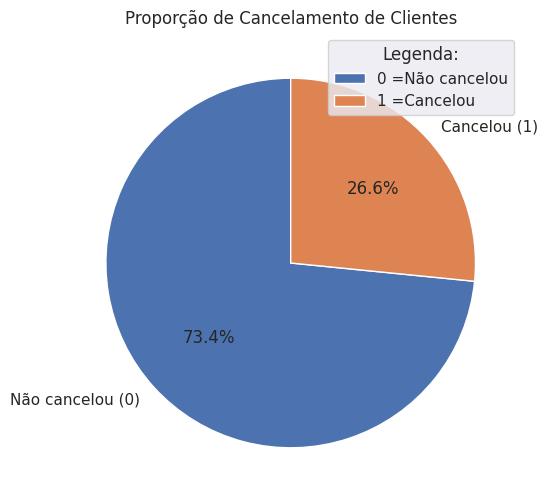

In [121]:
plt.figure(figsize=(6,6))

df['cancelou'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    labels=['Não cancelou (0)', 'Cancelou (1)']
)

plt.title('Proporção de Cancelamento de Clientes')
plt.ylabel('')

plt.legend(
    title='Legenda:',
    labels=['0 =Não cancelou', '1 =Cancelou'],
    loc='upper right'
)

plt.show()

In [122]:
colunas_categoricas = df.select_dtypes(include='object').columns

for col in colunas_categoricas:

    if col != 'id_cliente':  # ignora a coluna de identificação

        print(f'\nDistribuição da variável: {col}')

        frequencia = df[col].value_counts()
        percentual = df[col].value_counts(normalize=True) * 100

        tabela = pd.DataFrame({
            'Quantidade': frequencia,
            'Percentual (%)': percentual.round(2)
        })

        print(tabela)
        print('-' * 50)


Distribuição da variável: genero
           Quantidade  Percentual (%)
genero                               
Masculino        3549           50.47
Feminino         3483           49.53
--------------------------------------------------

Distribuição da variável: multiplas_linhas
                  Quantidade  Percentual (%)
multiplas_linhas                            
Não                     3385           48.14
Sim                     2967           42.19
Sem telefone             680            9.67
--------------------------------------------------

Distribuição da variável: servico_internet
                  Quantidade  Percentual (%)
servico_internet                            
Fibra ótica             3096           44.03
DSL                     2416           34.36
Sem internet            1520           21.62
--------------------------------------------------

Distribuição da variável: seguranca_online
                  Quantidade  Percentual (%)
seguranca_online                  

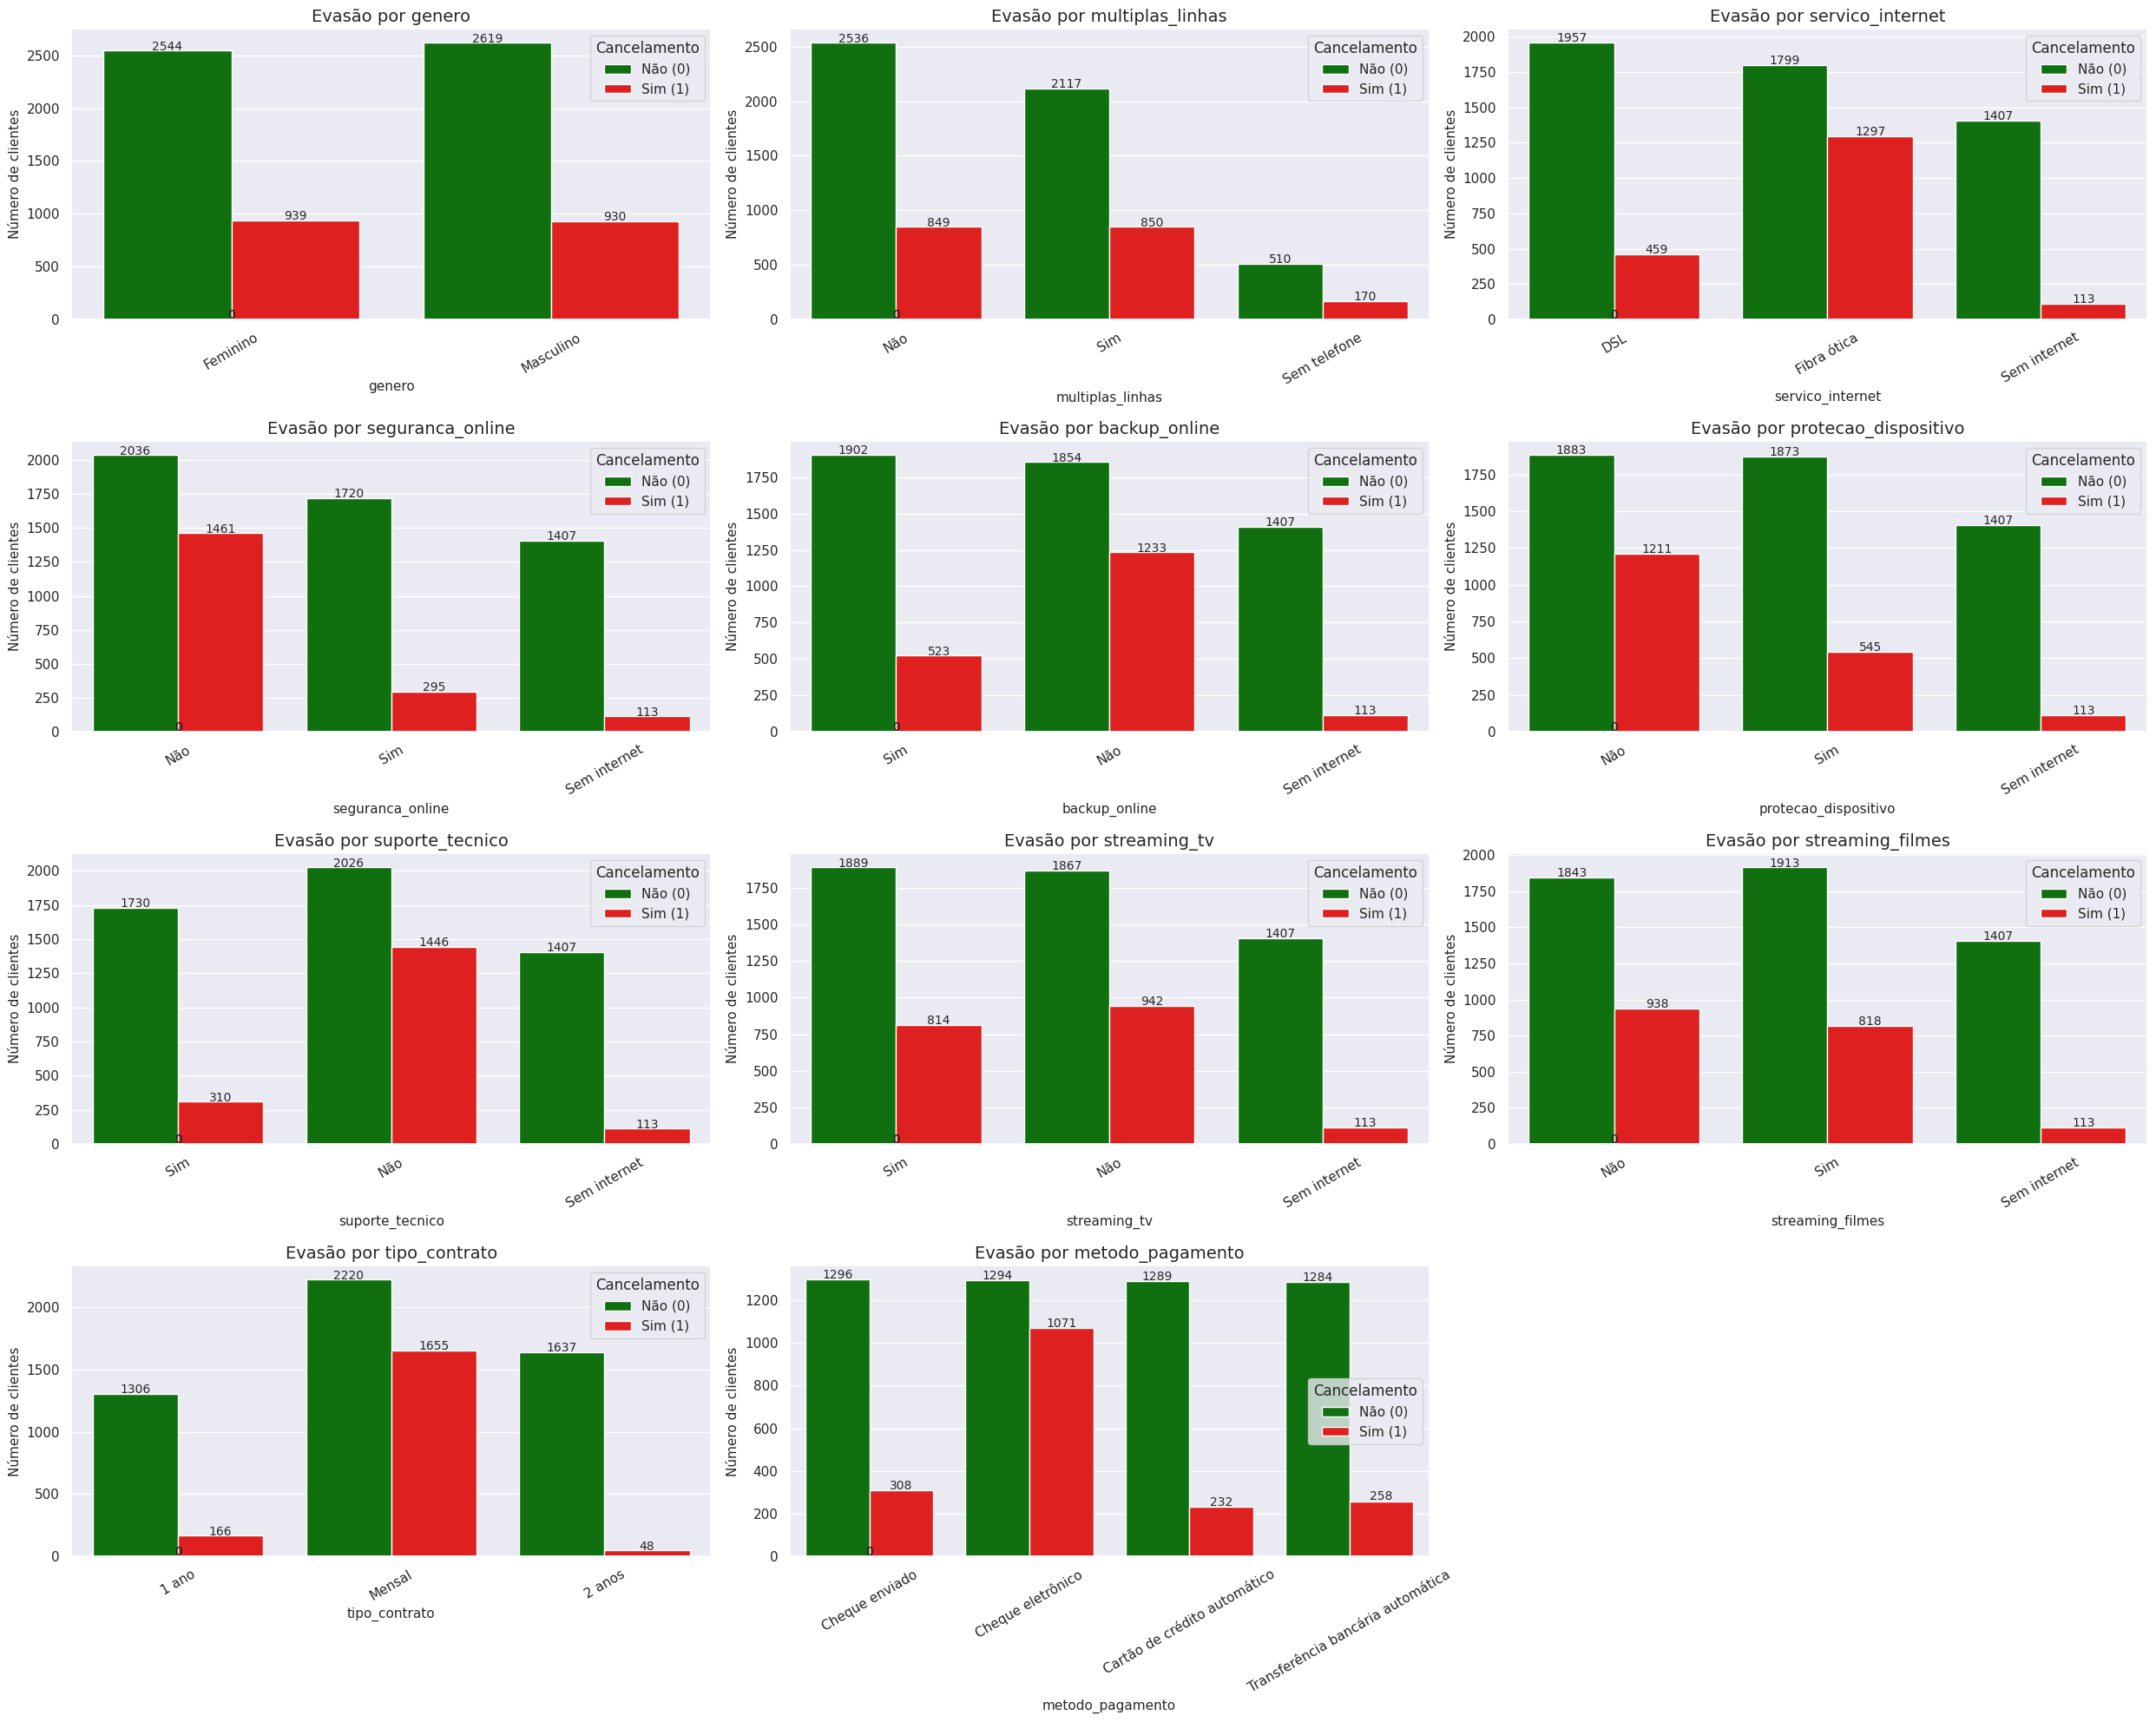

In [123]:
variaveis_categoricas = [
    'genero',
    'multiplas_linhas',
    'servico_internet',
    'seguranca_online',
    'backup_online',
    'protecao_dispositivo',
    'suporte_tecnico',
    'streaming_tv',
    'streaming_filmes',
    'tipo_contrato',
    'metodo_pagamento'
]

lista_variaveis = list(enumerate(variaveis_categoricas))

sns.set(rc={'figure.figsize':(25,20)})

for i in lista_variaveis:

    plt.subplot(4, 3, i[0] + 1)

    ax = sns.countplot(
        data=df,
        x=i[1],
        hue='cancelou',
        palette={0:'green', 1:'red'}
    )

    ax.set_title(f'Evasão por {i[1]}', fontsize=14)
    ax.set_ylabel('Número de clientes', fontsize=11)
    ax.set_xlabel(i[1], fontsize=11)

    plt.legend(title='Cancelamento', labels=['Não (0)', 'Sim (1)'])

    ax.tick_params(axis='x', rotation=30)

    # Adicionando os valores acima das barras
    for p in ax.patches:
        altura = p.get_height()
        ax.text(
            p.get_x() + p.get_width() / 2,
            altura + 5,
            int(altura),
            ha='center',
            fontsize=10
        )

plt.tight_layout()
plt.show()

In [124]:
import plotly.express as px

In [125]:
px.histogram(df, x = 'meses_contrato', text_auto = True, color = 'cancelou', barmode = 'group')

In [126]:
colunas_numericas = df.select_dtypes(include=['int64', 'float64']).columns

for col in colunas_numericas:
    print(f'\nDistribuição da variável: {col}')

    distribuicao = df[col].value_counts()
    percentual = df[col].value_counts(normalize=True) * 100

    tabela = pd.DataFrame({
        'Quantidade': distribuicao,
        'Percentual (%)': percentual.round(2)
    })

    print(tabela)
    print('-' * 50)


Distribuição da variável: cancelou
          Quantidade  Percentual (%)
cancelou                            
0               5163           73.42
1               1869           26.58
--------------------------------------------------

Distribuição da variável: idoso
       Quantidade  Percentual (%)
idoso                            
0            5890           83.76
1            1142           16.24
--------------------------------------------------

Distribuição da variável: parceiro
          Quantidade  Percentual (%)
parceiro                            
0               3639           51.75
1               3393           48.25
--------------------------------------------------

Distribuição da variável: dependentes
             Quantidade  Percentual (%)
dependentes                            
0                  4933           70.15
1                  2099           29.85
--------------------------------------------------

Distribuição da variável: meses_contrato
                Qu

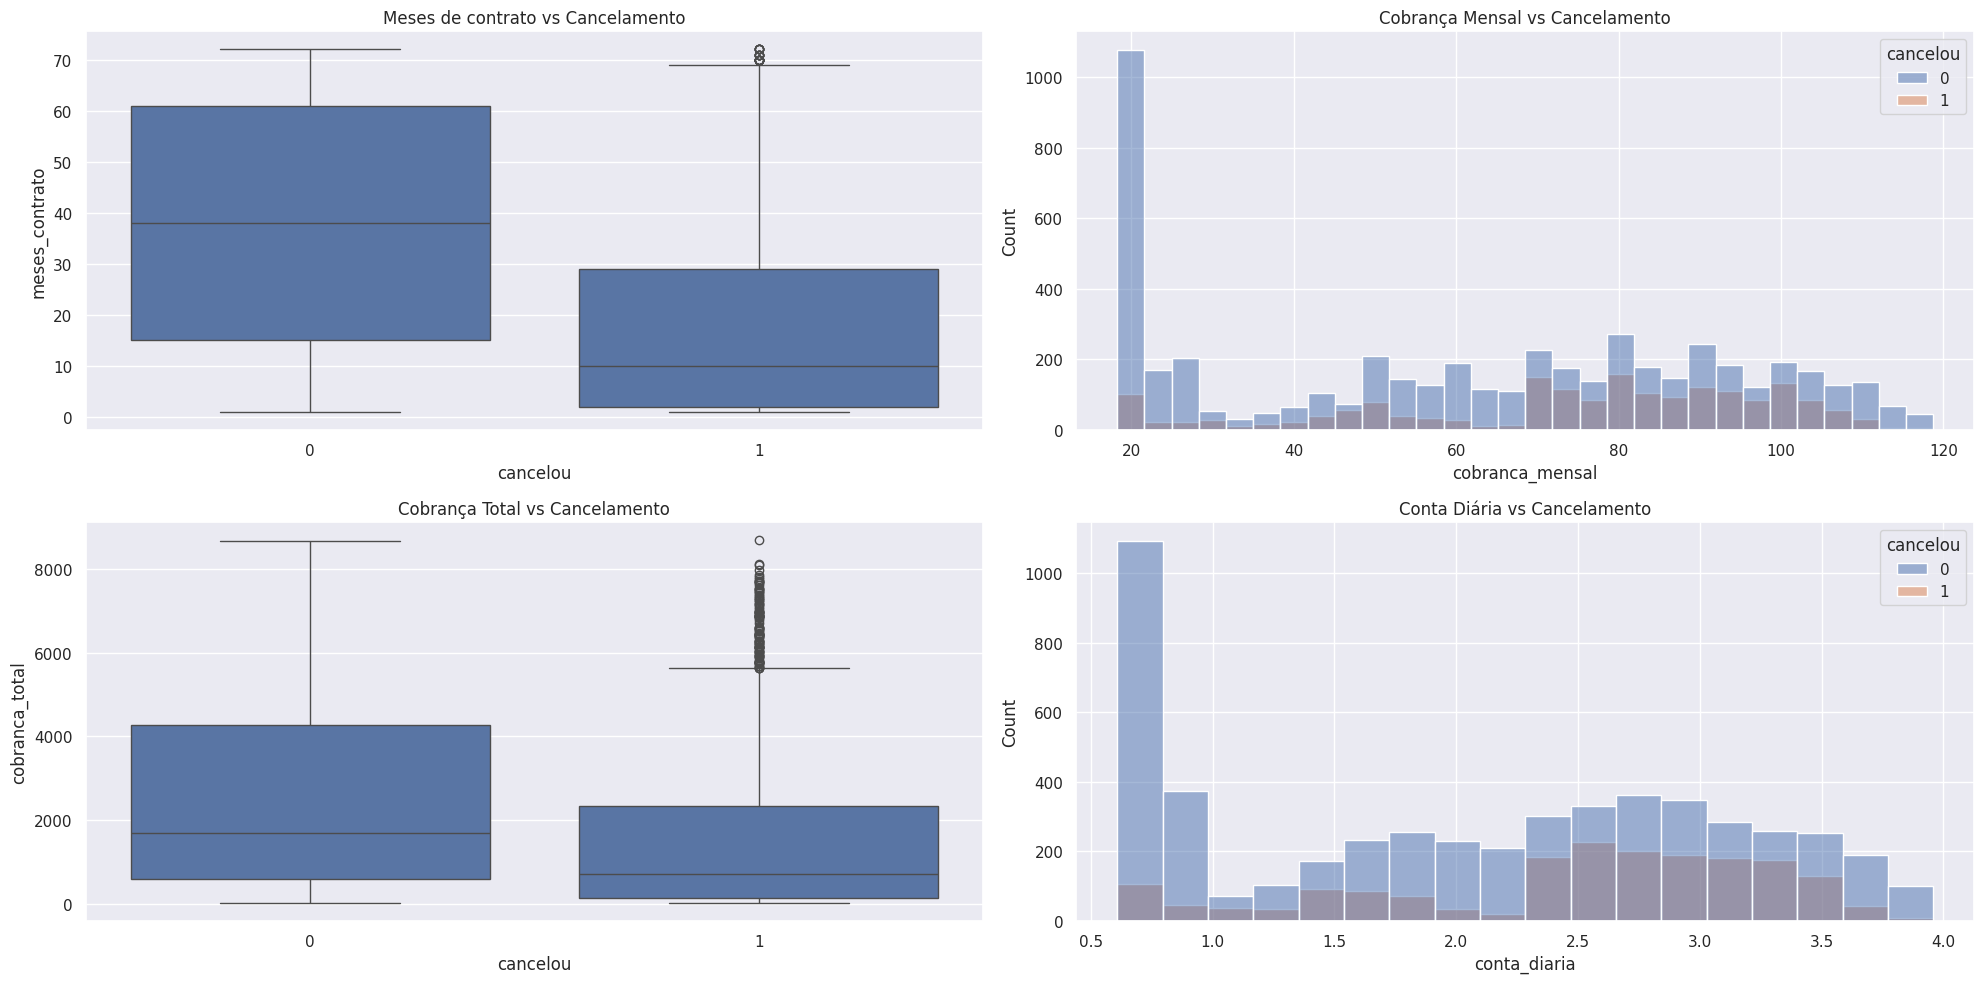

In [127]:
fig, axes = plt.subplots(2, 2, figsize=(20,10))

sns.boxplot(data=df, x='cancelou', y='meses_contrato', ax=axes[0,0])
axes[0,0].set_title('Meses de contrato vs Cancelamento')

sns.histplot(data=df, x='cobranca_mensal', hue='cancelou', bins=30, ax=axes[0,1])
axes[0,1].set_title('Cobrança Mensal vs Cancelamento')

sns.boxplot(data=df, x='cancelou', y='cobranca_total', ax=axes[1,0])
axes[1,0].set_title('Cobrança Total vs Cancelamento')

sns.histplot(data=df, x='conta_diaria', hue='cancelou', ax=axes[1,1])
axes[1,1].set_title('Conta Diária vs Cancelamento')

plt.tight_layout()
plt.show()

/tmp/ipykernel_439/2605620612.py:9: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



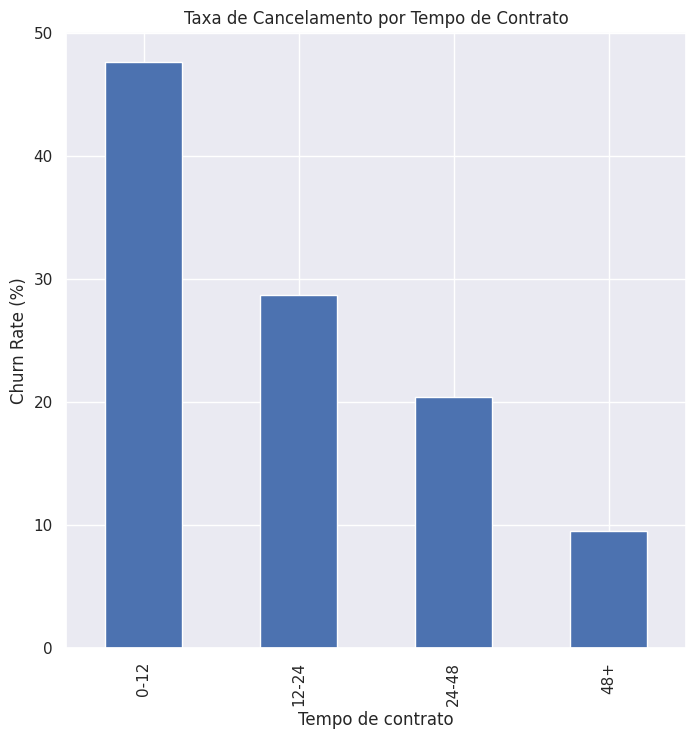

In [128]:
df['faixa_tempo'] = pd.cut(
    df['meses_contrato'],
    bins=[0,12,24,48,72],
    labels=['0-12','12-24','24-48','48+']
)

plt.figure(figsize=(8,8))

churn_rate = df.groupby('faixa_tempo')['cancelou'].mean() * 100

churn_rate.plot(kind='bar')


plt.title('Taxa de Cancelamento por Tempo de Contrato')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Tempo de contrato')

plt.show()

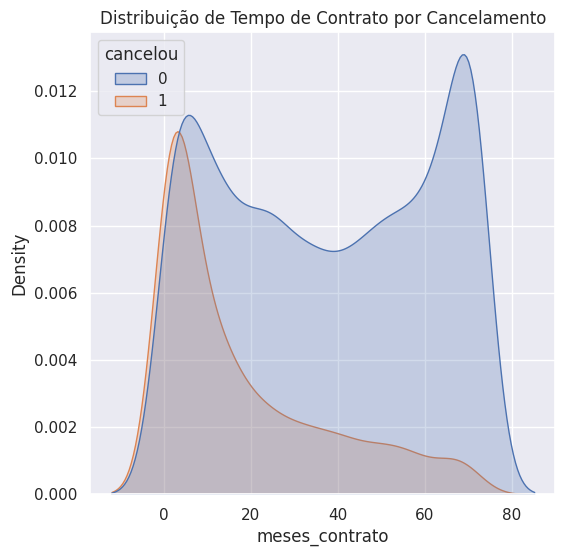

In [129]:
plt.figure(figsize=(6,6))

sns.kdeplot(
    data=df,
    x='meses_contrato',
    hue='cancelou',
    fill=True
)

plt.title('Distribuição de Tempo de Contrato por Cancelamento')
plt.show()

#📄 Relatorio Final

###📌 Introdução

A evasão de clientes, também conhecida como Churn, é um dos principais desafios enfrentados por empresas que trabalham com serviços recorrentes, como telecomunicações. A perda de clientes impacta diretamente a receita e pode indicar problemas relacionados à qualidade do serviço, preço ou experiência do cliente.

O objetivo deste projeto foi realizar uma análise exploratória de dados (EDA) para identificar padrões e fatores que possam estar associados ao cancelamento de clientes. A partir dessa análise, é possível compreender melhor o comportamento dos usuários e gerar insights que auxiliem na criação de estratégias para reduzir a evasão e aumentar a retenção de clientes.

---

###🧹 Limpeza e Tratamento de Dados

Inicialmente foi realizada a extração dos dados a partir de uma API, seguida pela transformação e preparação das informações para análise.

Durante essa etapa foram executadas as seguintes ações:


####Importação e inspeção inicial dos dados

Os dados foram carregados e analisados inicialmente para entender sua estrutura, tipos de variáveis e possíveis inconsistências.


####Padronização das colunas

Os nomes das colunas foram ajustados para um padrão mais organizado e de fácil manipulação dentro do ambiente de análise.


####Conversão de tipos de dados

A coluna cobranca_total foi convertida para o formato numérico, permitindo realizar análises estatísticas e visualizações adequadas.


####Tratamento de valores inconsistentes

Foi realizada uma verificação para identificar valores ausentes ou inconsistentes no dataset, garantindo maior confiabilidade nas análises.


####Tradução de valores categóricos

Algumas variáveis categóricas foram traduzidas para facilitar a interpretação dos dados.


####Conversão de variáveis binárias

Variáveis que possuíam valores como Sim / Não foram convertidas para 1 e 0, facilitando análises e manipulações futuras.


####Criação de nova variável

Foi criada a variável conta_diaria, derivada da cobrança mensal, permitindo analisar o comportamento de gastos dos clientes em uma escala diária.

Após essas etapas, o dataset ficou limpo, estruturado e pronto para análise exploratória.


---



###📊 Análise Exploratória de Dados

A análise exploratória foi realizada com o objetivo de compreender melhor os dados e identificar possíveis fatores associados à evasão de clientes.

Distribuição da evasão

O primeiro passo foi analisar a distribuição da variável cancelou, verificando a proporção de clientes que permaneceram e aqueles que cancelaram o serviço.

O gráfico de distribuição mostrou que:

A maior parte dos clientes permanece utilizando o serviço.

Uma parcela significativa realizou o cancelamento, caracterizando o churn.

Essa análise inicial permite entender o equilíbrio entre clientes ativos e cancelados, servindo como ponto de partida para as demais análises.


---


###📊 Análise das Variáveis Numéricas

Foram analisadas variáveis numéricas importantes relacionadas ao comportamento dos clientes, como:

meses de contrato

cobrança mensal

cobrança total

conta diária

Para essa análise foram utilizados boxplots e histogramas, permitindo comparar a distribuição dos valores entre clientes que cancelaram e os que permaneceram.

Tempo de contrato

A análise da variável meses_contrato mostrou que clientes que cancelaram tendem a possuir menor tempo de permanência no serviço.

Isso indica que os primeiros meses de contrato são um período crítico para retenção de clientes.

Cobrança mensal

A distribuição da variável cobranca_mensal mostrou diferenças entre os grupos, sugerindo que o valor pago mensalmente pode influenciar na decisão de cancelamento.

Clientes com valores mais elevados podem apresentar maior sensibilidade ao preço, o que pode contribuir para a evasão.

Cobrança total

Observou-se que clientes que cancelaram geralmente apresentam menor valor total gasto, o que reforça a hipótese de que muitos cancelamentos ocorrem nos primeiros meses de uso do serviço.

Conta diária

A variável conta_diaria, criada durante a transformação dos dados, ajudou a visualizar melhor o comportamento de gastos dos clientes, permitindo observar possíveis diferenças entre clientes que permanecem e aqueles que cancelam.


---

###📊 Análise das Variáveis Categóricas

Também foram analisadas diversas variáveis categóricas para identificar perfis de clientes com maior tendência ao cancelamento.

Entre as variáveis analisadas estão:

gênero

múltiplas linhas

serviço de internet

segurança online

backup online

proteção de dispositivo

suporte técnico

streaming de TV

streaming de filmes

tipo de contrato

método de pagamento

Foram utilizados gráficos de contagem (countplot) para visualizar a distribuição de clientes cancelados e não cancelados em cada categoria.

Principais padrões observados
Tipo de contrato

Um dos fatores mais relevantes observados foi o tipo de contrato.

Clientes com contrato mensal apresentaram maior número de cancelamentos quando comparados a clientes com contratos de longo prazo.

Isso sugere que contratos mais longos contribuem para maior retenção de clientes.

Serviços adicionais

Clientes que não possuem serviços adicionais, como:

segurança online

suporte técnico

backup online

tendem a apresentar maior número de cancelamentos.

Isso pode indicar que clientes com mais serviços contratados possuem maior engajamento com a plataforma.

Método de pagamento

Alguns métodos de pagamento apresentaram maior número de cancelamentos, o que pode estar relacionado ao perfil de clientes ou ao nível de fidelização.

---

###🧠 Conclusões e Insights

A análise exploratória permitiu identificar alguns padrões importantes relacionados à evasão de clientes.

Entre os principais insights encontrados:

Clientes com menor tempo de contrato apresentam maior probabilidade de cancelamento.

Contratos mensais possuem maior índice de churn quando comparados a contratos de longo prazo.

Clientes que possuem menos serviços adicionais tendem a cancelar mais o serviço.

O valor da cobrança mensal pode influenciar no comportamento de cancelamento.

Esses resultados mostram que fatores como tempo de permanência, tipo de contrato e serviços adicionais possuem forte relação com a evasão de clientes.

---

###🚀 Recomendações

Com base nos resultados da análise, algumas estratégias podem ser sugeridas para reduzir o churn:

Incentivar contratos de longo prazo

Oferecer descontos ou benefícios para clientes que optarem por contratos anuais ou de maior duração.

Melhorar retenção nos primeiros meses

Criar programas de onboarding e acompanhamento para novos clientes, reduzindo cancelamentos no início do contrato.

Promover serviços adicionais

Estimular a adesão a serviços como segurança online, suporte técnico e backup, aumentando o valor percebido pelo cliente.

Monitorar clientes com maior risco de churn

Utilizar os padrões identificados na análise para desenvolver estratégias de retenção direcionadas.